# Fine-tuning médical QLoRA — Challenge IA TechCorp (volet expérimental)

**Filière IA — branche `groupe-ia-1`** · modèle base : `microsoft/Phi-3.5-mini-instruct` (aligné sur la base propre de prod).

Objectif : fine-tuner un assistant médical **expérimental** (démo, non déployé en prod) en QLoRA 4-bit sur un sous-échantillon de `ruslanmv/ai-medical-chatbot`.

## Comment utiliser ce notebook
1. Ouvrir dans **Google Colab**, menu `Exécution > Modifier le type d'exécution` → **GPU T4** (gratuit).
2. Exécuter les cellules dans l'ordre. Durée totale attendue : ~15-30 min sur T4 (500 exemples, 3 epochs).
3. À la fin : récupérer les **métriques** (loss, epochs, temps) et la **courbe de loss** affichées, et les reporter dans `rendu/ia/`.
4. **Partager le notebook** : `Partager` (haut droite) → *Tous les utilisateurs disposant du lien* → **Lecteur**, puis coller le lien dans `rendu/ia/README.md`.

> ⚠️ Modèle **expérimental** : ne remplace pas un avis médical, non déployé en production (cf. `SUIVI_PROJET.md`).


## 0. Vérifier le GPU


In [1]:
!nvidia-smi

Wed Jul  1 17:01:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Installer les dépendances
Versions épinglées pour la reproductibilité sur Colab (juillet 2026 : ajuster si conflit).


In [2]:
!pip install -q -U transformers trl peft bitsandbytes accelerate \
         datasets huggingface_hub matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.8/838.8 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.1/721.1 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 14.7 MB/s eta 0:00:00


## 2. Imports & configuration


In [3]:
import os, time, random, json
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from datasets import Dataset
from transformers import (AutoModelForCausalLM, AutoTokenizer,
                          BitsAndBytesConfig, TrainingArguments)
from peft import LoraConfig, prepare_model_for_kbit_training
from trl import SFTTrainer, SFTConfig

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

BASE_MODEL   = "microsoft/Phi-3.5-mini-instruct"
N_SAMPLES    = 500      # sous-echantillon volontairement reduit (demo)
N_EPOCHS     = 3        # 2-3 suffisent pour une demo
MAX_SEQ_LEN  = 1024
OUTPUT_DIR   = "phi35-medical-qlora"
print("torch", torch.__version__, "| CUDA dispo:", torch.cuda.is_available())

torch 2.11.0+cu128 | CUDA dispo: True


## 3. Charger et sous-échantillonner le dataset
Source : [`ruslanmv/ai-medical-chatbot`](https://huggingface.co/datasets/ruslanmv/ai-medical-chatbot) — ~256 916 dialogues, colonnes `Description`, `Patient`, `Doctor`.
On nettoie (doublons, vides, longueurs aberrantes) puis on réduit à 500 exemples reproductibles (seed 42).


In [4]:
from huggingface_hub import hf_hub_download
path = hf_hub_download('ruslanmv/ai-medical-chatbot', 'dialogues.parquet', repo_type='dataset')
df = pd.read_parquet(path, columns=['Description', 'Patient', 'Doctor'])
print('brut:', len(df), 'lignes')

# --- Nettoyage ---
df = df.dropna(subset=['Patient', 'Doctor'])
df['Patient'] = df['Patient'].str.strip()
df['Doctor']  = df['Doctor'].str.strip()
df = df[(df['Patient'].str.len() > 15) & (df['Doctor'].str.len() > 20)]
df = df[df['Patient'].str.len() < 2000]           # ecarte les questions aberrantes
df = df.drop_duplicates(subset=['Patient'])
print('apres nettoyage:', len(df), 'lignes')

# --- Sous-echantillon reproductible ---
sample = df.sample(n=N_SAMPLES, random_state=SEED).reset_index(drop=True)
sample.to_json('medical_sample_500.jsonl', orient='records', lines=True, force_ascii=False)
print('sous-echantillon:', len(sample), 'exemples -> medical_sample_500.jsonl')
sample.head(2)

dialogues.parquet:   0%|          | 0.00/142M [00:00<?, ?B/s]

brut: 256916 lignes
apres nettoyage: 244696 lignes
sous-echantillon: 500 exemples -> medical_sample_500.jsonl


,Description,Patient,Doctor
0,"Kidney stones, enlarged liver, spleen, not a h...",My son is 38 years old. He recently passed sev...,HiThanks for the query.Kidney stones can cause...
1,What causes the ups and downs in the blood pre...,"i am 52 year old woman, overweight and trying ...",HiActually a reading of 152/75 after being act...


## 4. Mise au format chat Phi-3.5
On formate chaque paire en conversation `messages` (system / user / assistant), puis le template applique les balises `<|user|> … <|end|> <|assistant|>`.


In [5]:
SYSTEM_PROMPT = ('You are a careful medical assistant. Provide helpful, factual health information. '
                 'You are not a doctor: always advise consulting a qualified professional for diagnosis or treatment.')

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.unk_token or tokenizer.eos_token

def to_text(row):
    msgs = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user', 'content': row['Patient']},
        {'role': 'assistant', 'content': row['Doctor']},
    ]
    return tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=False)

sample['text'] = sample.apply(to_text, axis=1)
ds = Dataset.from_pandas(sample[['text']])
split = ds.train_test_split(test_size=0.1, seed=SEED)
train_ds, eval_ds = split['train'], split['test']
print('train', len(train_ds), '| eval', len(eval_ds))
print(train_ds[0]['text'][:400])

config.json:   0%|          | 0.00/3.45k [00:00<?, ?B/s]

configuration_phi3.py:   0%|          | 0.00/11.2k [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/microsoft/Phi-3.5-mini-instruct:
- configuration_phi3.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
[transformers] This model config has set a `rope_parameters['original_max_position_embeddings']` field, to be used together with `max_position_embeddings` to determine a scaling factor. Please set the `factor` field of `rope_parameters`with this ratio instead -- we recommend the use of this field over `original_max_position_embeddings`, as it is compatible with most model architectures.


tokenizer_config.json:   0%|          | 0.00/3.98k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

train 450 | eval 50
<|system|>
You are a careful medical assistant. Provide helpful, factual health information. You are not a doctor: always advise consulting a qualified professional for diagnosis or treatment.<|end|>
<|user|>
I have a pulsating sensation in my calf, there is no swelling, heat or pain, just a constant pulsating sensation that will temporarily ease when moved into another position, is this something


## 5. Charger Phi-3.5 en 4-bit (QLoRA) + config LoRA


In [6]:
bnb = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)
model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL, quantization_config=bnb, device_map='auto', trust_remote_code=True,
)
model = prepare_model_for_kbit_training(model)
model.config.use_cache = False

lora = LoraConfig(
    r=16, lora_alpha=32, lora_dropout=0.05, bias='none', task_type='CAUSAL_LM',
    target_modules=['qkv_proj', 'o_proj', 'gate_up_proj', 'down_proj'],  # modules Phi-3.5
)

modeling_phi3.py:   0%|          | 0.00/73.8k [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/microsoft/Phi-3.5-mini-instruct:
- modeling_phi3.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors.index.json:   0%|          | 0.00/16.3k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/195 [00:00<?, ?B/s]

## 6. Entraînement (SFTTrainer) + chronométrage


In [8]:
cfg = SFTConfig(
    output_dir=OUTPUT_DIR,
    num_train_epochs=N_EPOCHS,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    lr_scheduler_type='cosine',
    warmup_ratio=0.03,
    logging_steps=10,
    eval_strategy='epoch',
    save_strategy='epoch',
    bf16=True,
    max_length=MAX_SEQ_LEN,
    dataset_text_field='text',
    report_to='none',
    seed=SEED,
)
trainer = SFTTrainer(
    model=model, args=cfg, train_dataset=train_ds, eval_dataset=eval_ds,
    peft_config=lora, processing_class=tokenizer,
)
t0 = time.time()
train_result = trainer.train()
train_time = time.time() - t0
print(f'\n=== Entrainement termine en {train_time/60:.1f} min ===')

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Adding EOS to train dataset:   0%|          | 0/450 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/450 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/450 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/50 [00:00<?, ? examples/s]

...

Building labels for eval dataset:   0%|          | 0/50 [00:00<?, ? examples/s]

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:202: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is de

Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,7.185875,7.037706,6.786611,126245.000000,0.169759
2,6.757475,6.751789,6.825005,252490.000000,0.187716
3,6.676919,6.677965,6.744095,378735.000000,0.198090


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:202: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 


=== Entrainement termine en 94.7 min ===


## 7. Métriques & courbe de loss (à reporter dans le rendu)


{
  "base_model": "microsoft/Phi-3.5-mini-instruct",
  "n_samples": 500,
  "epochs": 3,
  "train_time_min": 94.69,
  "final_train_loss": 6.6769,
  "final_eval_loss": 6.678
}


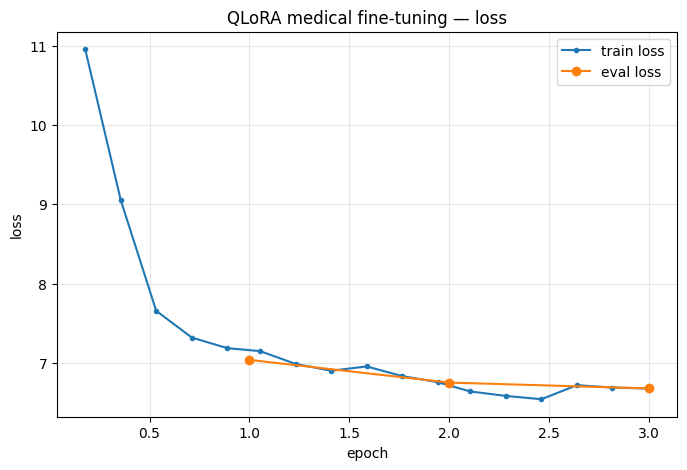

In [9]:
hist = trainer.state.log_history
train_pts = [(h['epoch'], h['loss']) for h in hist if 'loss' in h]
eval_pts  = [(h['epoch'], h['eval_loss']) for h in hist if 'eval_loss' in h]

metrics = {
    'base_model': BASE_MODEL,
    'n_samples': N_SAMPLES,
    'epochs': N_EPOCHS,
    'train_time_min': round(train_time/60, 2),
    'final_train_loss': round(train_pts[-1][1], 4) if train_pts else None,
    'final_eval_loss': round(eval_pts[-1][1], 4) if eval_pts else None,
}
print(json.dumps(metrics, indent=2))
with open('training_metrics.json', 'w') as f: json.dump(metrics, f, indent=2)

plt.figure(figsize=(8,5))
if train_pts: plt.plot(*zip(*train_pts), label='train loss', marker='.')
if eval_pts:  plt.plot(*zip(*eval_pts), label='eval loss', marker='o')
plt.xlabel('epoch'); plt.ylabel('loss'); plt.title('QLoRA medical fine-tuning — loss')
plt.legend(); plt.grid(alpha=.3); plt.savefig('loss_curve.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Sauvegarde de l'adapter LoRA


In [10]:
trainer.model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print('adapter sauvegarde dans', OUTPUT_DIR)
# Optionnel : telecharger l'adapter + les artefacts
# from google.colab import files; files.download('loss_curve.png'); files.download('training_metrics.json')

adapter sauvegarde dans phi35-medical-qlora


## 9. Tests de validation (quelques questions médicales)
Petit contrôle qualitatif du modèle fine-tuné.


In [12]:
from transformers import pipeline
model.config.use_cache = True
gen = pipeline('text-generation', model=trainer.model, tokenizer=tokenizer)

val_questions = [
    'What are common symptoms of type 2 diabetes?',
    'I have had a mild headache and a runny nose for two days. What could it be?',
    'Is it safe to take ibuprofen and paracetamol together?',
    'What lifestyle changes help lower high blood pressure?',
]
for q in val_questions:
    msgs = [{'role':'system','content':SYSTEM_PROMPT}, {'role':'user','content':q}]
    prompt = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    out = gen(prompt, max_new_tokens=256, do_sample=False, use_cache=False)[0]['generated_text']
    print('Q:', q)
    print('A:', out[len(prompt):].strip(), '\n' + '-'*80)

[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens', 'use_cache'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172:

Q: What are common symptoms of type 2 diabetes?
A: Hi, I have a a is and and my and and my and and it is and it is and it is. I have a and and is 200. I am a 200. I have a to the a. I have a to the a. I have a to the a. I have a the 100. 
--------------------------------------------------------------------------------


[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: I have had a mild headache and a runny nose for two days. What could it be?
A: Hi, I have a and 30. I am a 200 old. I have a a. I have a to the a. I have a to. I have a to. I have a to. I have a to. I have a to. I have a. I have a to. I have a. I have a to. I have a. I have a. 
--------------------------------------------------------------------------------


[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: Is it safe to take ibuprofen and paracetamol together?
A: Hi, I have a and 30. I am a and and I have a and and I have a and and I have a and. I have a and. I have a and. I have a to. I have a to. I am a to. I have a to. I can I have a. I have a to. I can a to. I have a to. I have a to. I have a. I have a. I have a. I have a. I have I have to the I have. I have I have to to the a. I have I have to to the a. I have a. I have a. I have a to. I have a. I have a. I have a. I have a. I have a. I have a. I have a. I have a. I have a. I have a. I have a. I have to to to. I have I have to to the a. I have to to the a. I have. 
--------------------------------------------------------------------------------
Q: What lifestyle changes help lower high blood pressure?
A: Hi, I have a a 100 old for it 200 old and and I have a and 2000 have and I have a and 2000 am 2000 am 201 my. I have a to the a. I have a to the a. I have a. I have a to the a. I have a to the a. 
--------------------------------

---
### À reporter dans `rendu/ia/`
- Le **lien Colab** (partagé en lecture) → `rendu/ia/README.md`.
- `training_metrics.json` (loss finale, epochs, temps) et `loss_curve.png`.
- Quelques réponses de la cellule 9 comme échantillon de validation.

**Rappel** : modèle médical = expérimental, **pas de déploiement prod**.
